# Credit Card Fraud Detection - Model Comparison and Visualization

This notebook compiles, compares, and visualizes the performance of all three supervised classifiers:
1. Logistic Regression
2. Random Forest
3. XGBoost Classifier

We evaluate them under both **Random Undersampling** and **SMOTE** techniques, plotting their ROC curves, Precision-Recall curves, confusion matrices, and metric bar charts side-by-side to visually inspect performance tradeoffs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the dataset
df = pd.read_csv('creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# Preprocess and scale features
scaler = RobustScaler()
X_scaled = X.copy()
X_scaled[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])
print("Features scaled successfully.")

Features scaled successfully.


In [4]:
# Split data into train and test sets (stratified 80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (227845, 30), Test size: (56962, 30)


In [5]:
# Apply resampling techniques to training data
# 1. Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# 2. SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Undersampling and SMOTE datasets prepared.")

Undersampling and SMOTE datasets prepared.


In [6]:
# Define models dictionary
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss', n_jobs=-1)
}
print("Models dictionary initialized.")

Models dictionary initialized.


In [7]:
# Train and evaluate models on Undersampled data
results_under = {}
for name, model in models.items():
    # For undersampled Random Forest, we can let it train without max_depth limit to get maximum detail
    if name == 'Random Forest':
        clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    else:
        clf = model
        
    print(f"Training {name} on undersampled data...")
    clf.fit(X_train_under, y_train_under)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = auc(recall_vals, precision_vals)
    
    results_under[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'fpr': fpr,
        'tpr': tpr,
        'precision_vals': precision_vals,
        'recall_vals': recall_vals,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    }
print("Undersampled evaluations completed.")

Training Logistic Regression on undersampled data...
Training Random Forest on undersampled data...
Training XGBoost on undersampled data...
Undersampled evaluations completed.


In [8]:
# Train and evaluate models on SMOTE data
results_smote = {}
for name, model in models.items():
    print(f"Training {name} on SMOTE data...")
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = auc(recall_vals, precision_vals)
    
    results_smote[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'fpr': fpr,
        'tpr': tpr,
        'precision_vals': precision_vals,
        'recall_vals': recall_vals,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    }
print("SMOTE evaluations completed.")

Training Logistic Regression on SMOTE data...
Training Random Forest on SMOTE data...
Training XGBoost on SMOTE data...
SMOTE evaluations completed.


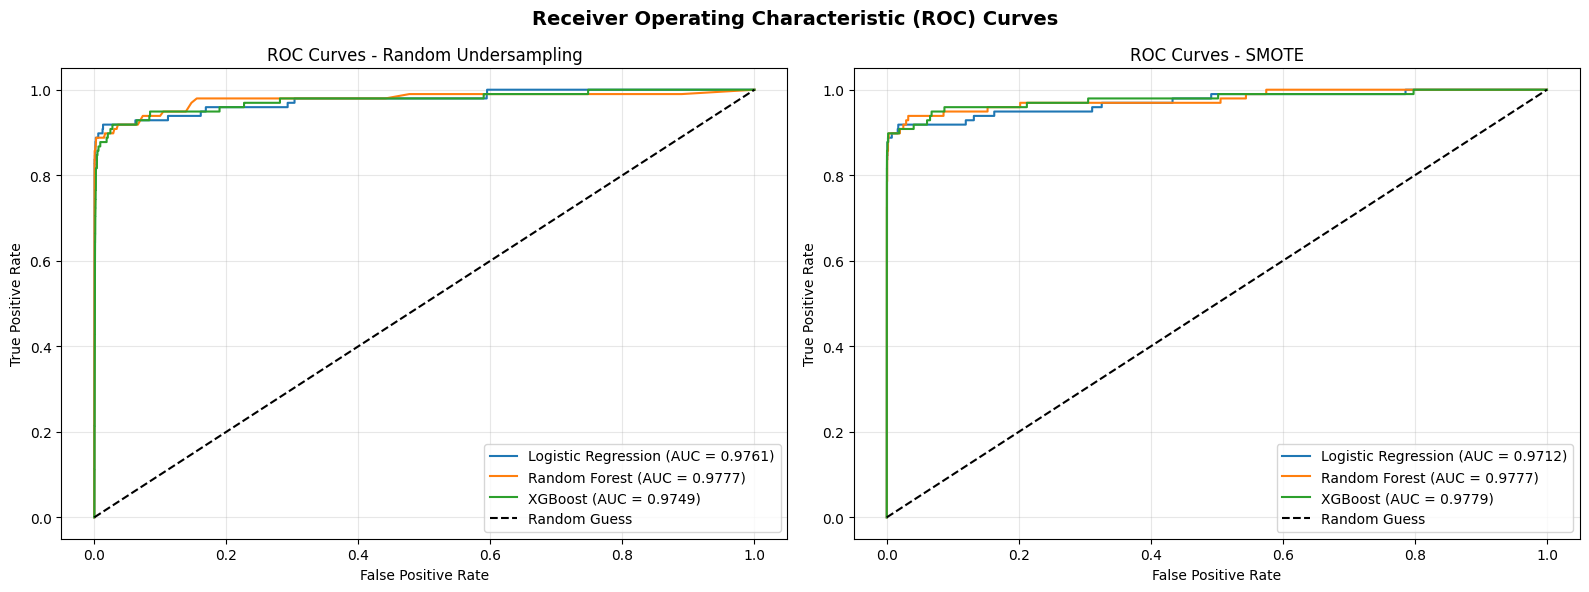

In [9]:
# Visualize Receiver Operating Characteristic (ROC) Curves
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Undersampling ROC Curves
for name, res in results_under.items():
    ax[0].plot(res['fpr'], res['tpr'], label=f"{name} (AUC = {res['roc_auc']:.4f})")
ax[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax[0].set_title('ROC Curves - Random Undersampling')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc='lower right')
ax[0].grid(True, alpha=0.3)

# SMOTE ROC Curves
for name, res in results_smote.items():
    ax[1].plot(res['fpr'], res['tpr'], label=f"{name} (AUC = {res['roc_auc']:.4f})")
ax[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax[1].set_title('ROC Curves - SMOTE')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc='lower right')
ax[1].grid(True, alpha=0.3)

plt.suptitle('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

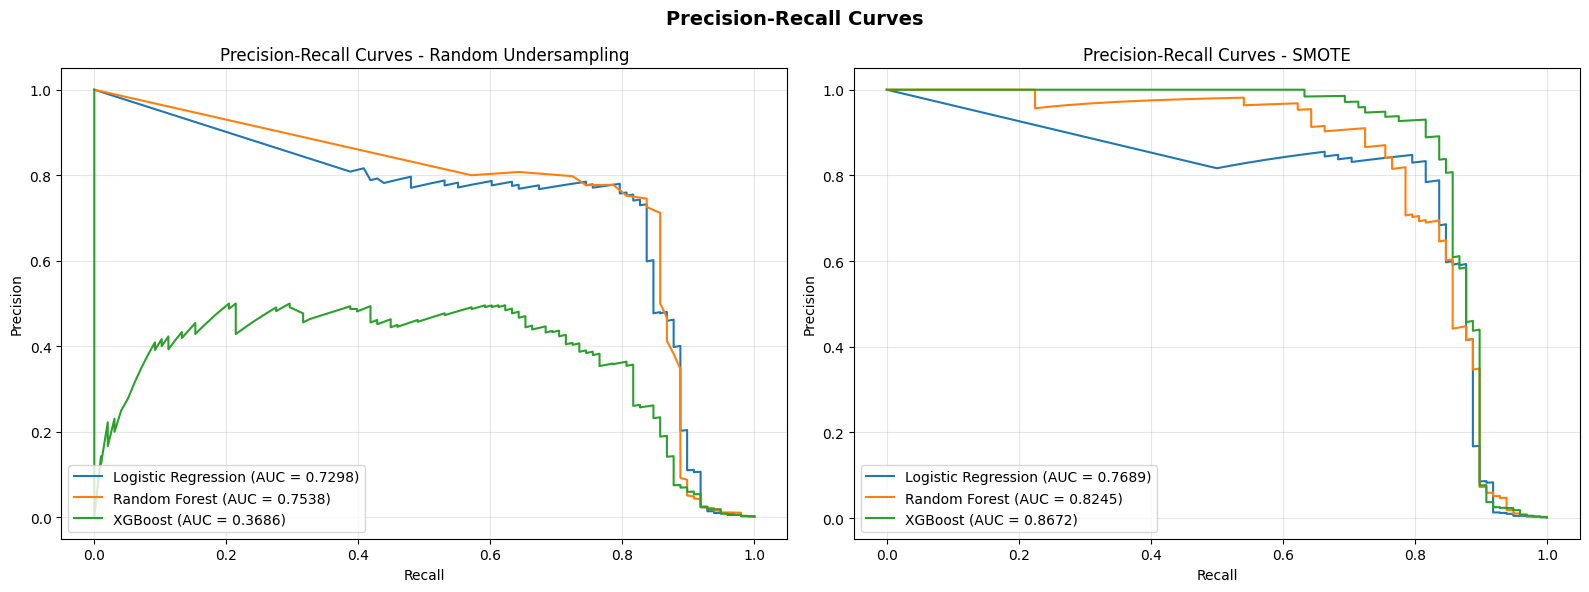

In [10]:
# Visualize Precision-Recall Curves (crucial for imbalanced data)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Undersampling PR Curves
for name, res in results_under.items():
    ax[0].plot(res['recall_vals'], res['precision_vals'], label=f"{name} (AUC = {res['pr_auc']:.4f})")
ax[0].set_title('Precision-Recall Curves - Random Undersampling')
ax[0].set_xlabel('Recall')
ax[0].set_ylabel('Precision')
ax[0].legend(loc='lower left')
ax[0].grid(True, alpha=0.3)

# SMOTE PR Curves
for name, res in results_smote.items():
    ax[1].plot(res['recall_vals'], res['precision_vals'], label=f"{name} (AUC = {res['pr_auc']:.4f})")
ax[1].set_title('Precision-Recall Curves - SMOTE')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc='lower left')
ax[1].grid(True, alpha=0.3)

plt.suptitle('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

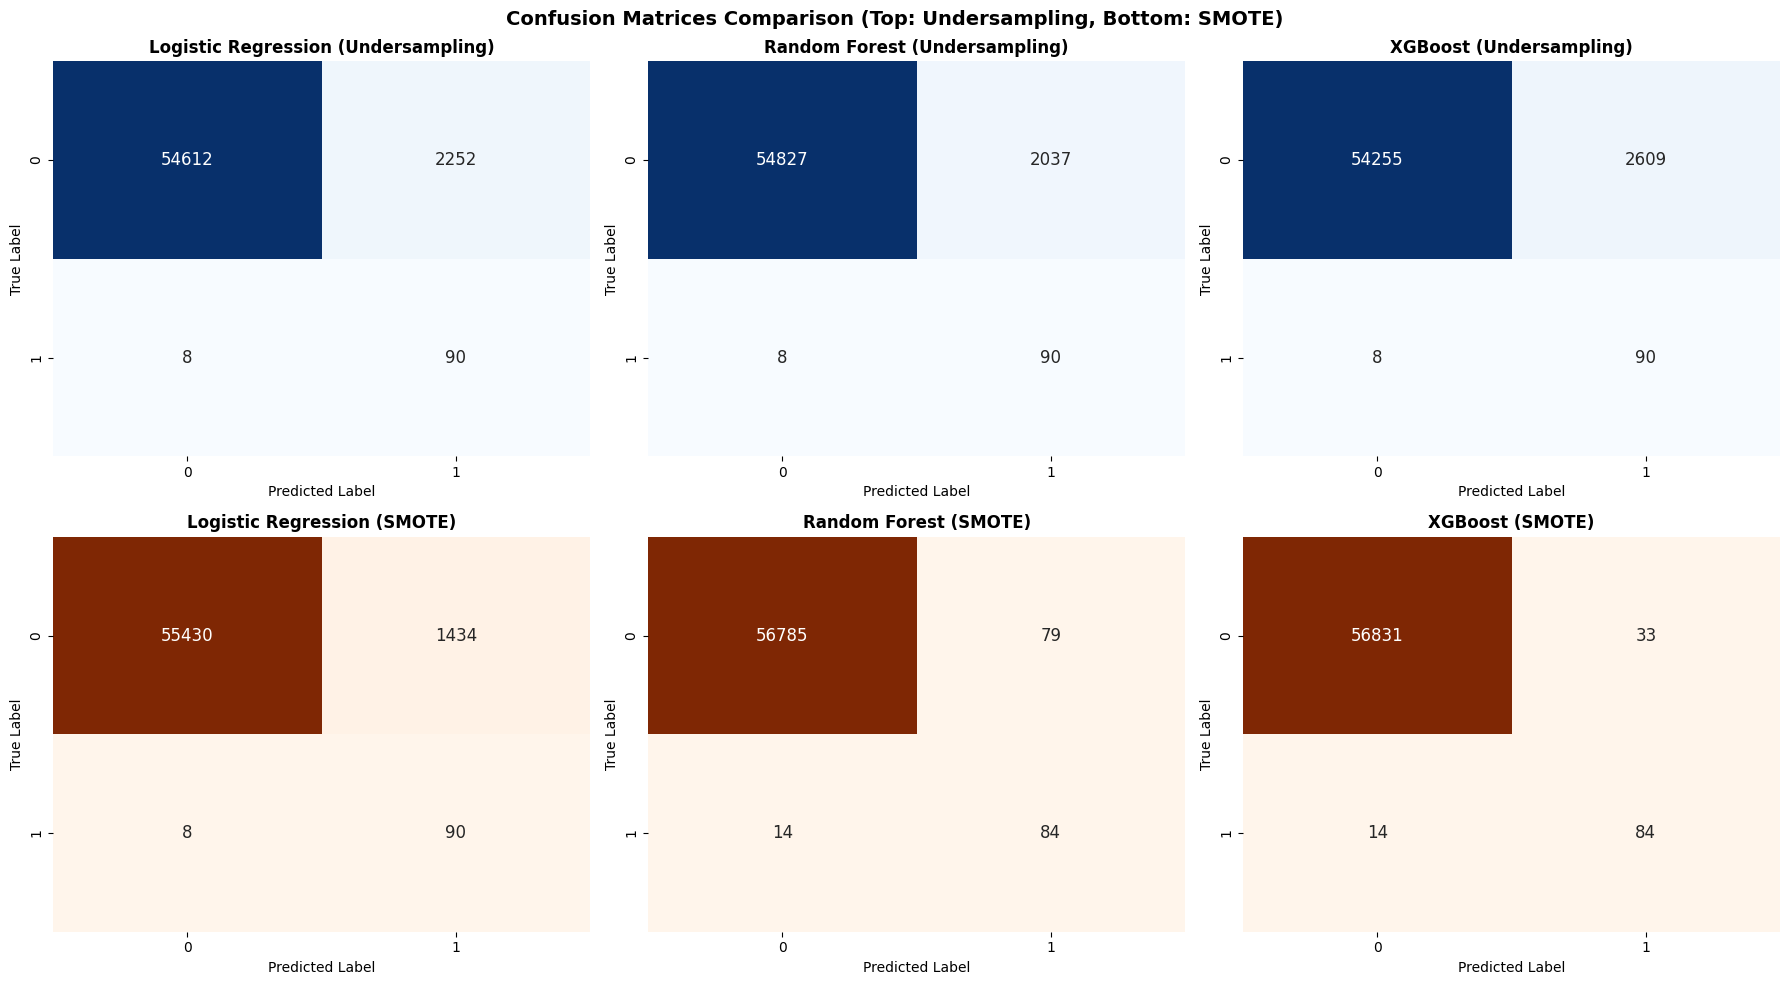

In [11]:
# Plot and Compare Confusion Matrices for all 3 models under both resampling setups
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot Undersampled Confusion Matrices
for idx, (name, res) in enumerate(results_under.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx], cbar=False, annot_kws={'size': 12})
    axes[0, idx].set_title(f"{name} (Undersampling)", fontweight='bold')
    axes[0, idx].set_xlabel('Predicted Label')
    axes[0, idx].set_ylabel('True Label')

# Plot SMOTE Confusion Matrices
for idx, (name, res) in enumerate(results_smote.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1, idx], cbar=False, annot_kws={'size': 12})
    axes[1, idx].set_title(f"{name} (SMOTE)", fontweight='bold')
    axes[1, idx].set_xlabel('Predicted Label')
    axes[1, idx].set_ylabel('True Label')

plt.suptitle('Confusion Matrices Comparison (Top: Undersampling, Bottom: SMOTE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Compile final comparative metrics DataFrame
from sklearn.metrics import precision_recall_fscore_support

comparison_data = []
for name, res in results_under.items():
    p, r, f, _ = precision_recall_fscore_support(y_test, res['y_pred'], average=None)
    comparison_data.append({
        'Model': name,
        'Sampling': 'Undersampling',
        'Precision': p[1],
        'Recall': r[1],
        'F1-score': f[1],
        'ROC-AUC': res['roc_auc'],
        'PR-AUC': res['pr_auc']
    })

for name, res in results_smote.items():
    p, r, f, _ = precision_recall_fscore_support(y_test, res['y_pred'], average=None)
    comparison_data.append({
        'Model': name,
        'Sampling': 'SMOTE',
        'Precision': p[1],
        'Recall': r[1],
        'F1-score': f[1],
        'ROC-AUC': res['roc_auc'],
        'PR-AUC': res['pr_auc']
    })

comparison_df = pd.DataFrame(comparison_data)
print("Summary Table of Model Comparison Metrics (Class 1 / Fraud):")
comparison_df

Summary Table of Model Comparison Metrics (Class 1 / Fraud):


,Model,Sampling,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,Undersampling,0.038429,0.918367,0.073770,0.976060,0.729838
1,Random Forest,Undersampling,0.042313,0.918367,0.080899,0.977698,0.753826
2,XGBoost,Undersampling,0.033346,0.918367,0.064355,0.974863,0.368646
3,Logistic Regression,SMOTE,0.059055,0.918367,0.110974,0.971219,0.768883
4,Random Forest,SMOTE,0.515337,0.857143,0.643678,0.977669,0.824534
5,XGBoost,SMOTE,0.717949,0.857143,0.781395,0.977898,0.867180


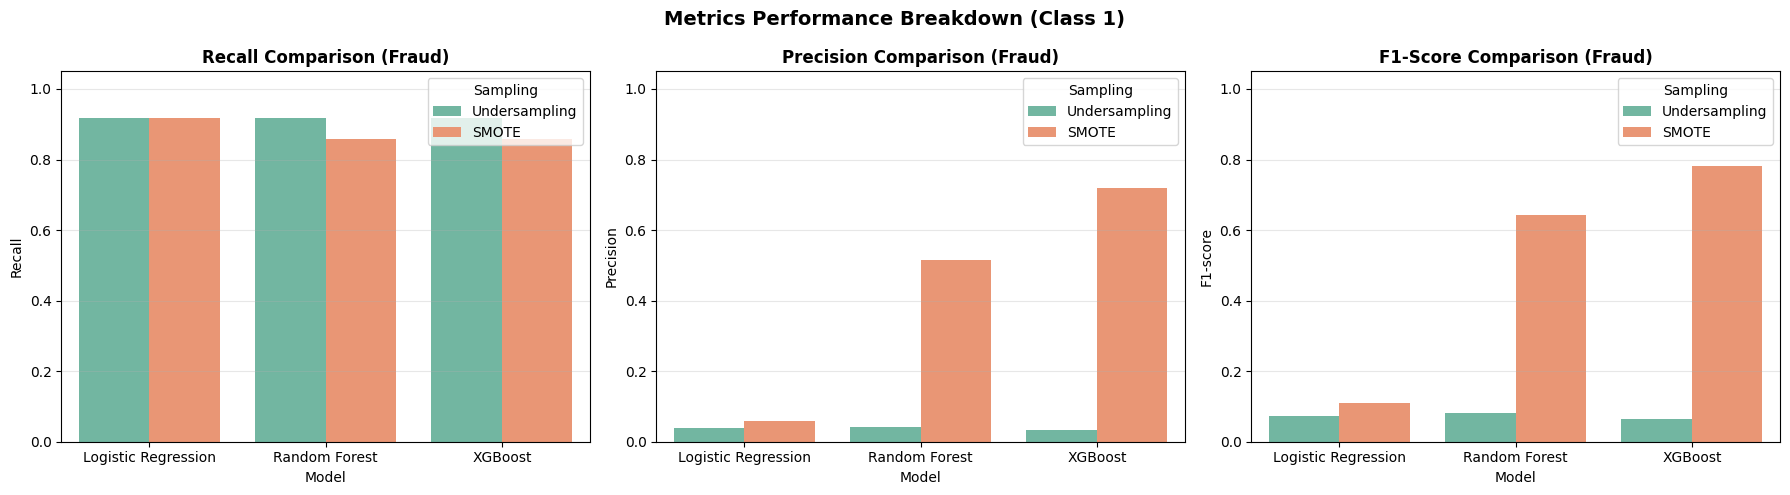

In [13]:
# Plot side-by-side metric bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar plot for Recall
sns.barplot(x='Model', y='Recall', hue='Sampling', data=comparison_df, ax=axes[0], palette='Set2')
axes[0].set_title('Recall Comparison (Fraud)', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)

# Bar plot for Precision
sns.barplot(x='Model', y='Precision', hue='Sampling', data=comparison_df, ax=axes[1], palette='Set2')
axes[1].set_title('Precision Comparison (Fraud)', fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

# Bar plot for F1-score
sns.barplot(x='Model', y='F1-score', hue='Sampling', data=comparison_df, ax=axes[2], palette='Set2')
axes[2].set_title('F1-Score Comparison (Fraud)', fontweight='bold')
axes[2].set_ylim(0, 1.05)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Metrics Performance Breakdown (Class 1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()